In [1]:
import gc
import numpy as np  
import pandas as pd  
import seaborn as sns  
import warnings 
import nltk
import string
import torch

import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt 
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, log_loss, roc_auc_score, ndcg_score

from scipy.sparse import csr_matrix

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from bertopic import BERTopic
from torch.utils.data import Dataset, DataLoader

from surprise import SVD, Dataset, Reader

warnings.filterwarnings('ignore') 
tqdm.pandas()
nltk.download('stopwords')
nltk.download('punkt')
%matplotlib inline

c:\TSU\RECOMMENDER_SYSTEMS\BooksRecs\venv_books\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dima\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dima\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Загрузка данных
books = pd.read_csv('data/books.csv')
book_tags = pd.read_csv('data/book_tags.csv')
ratings = pd.read_csv('data/ratings.csv')
tags = pd.read_csv('data/tags.csv')

# <center> **Подготовка данных**

In [4]:
# Список числовых признаков
books_numeric = [x for x in books.columns if books[x].dtype != 'object']

# Проверим диапазон значений
for col in books_numeric:
    print(f'{col}: {books[col].min()} - {books[col].max()}')
    
    
# Преобразование типов данных
# uint16: books_count
# int16: original_publication_year
# uint32: остальные целочисленные, кроме идентификаторов
# int64: isbn13
# float16: average_rating
books['books_count'] = books['books_count'].astype('uint16')
books['original_publication_year'] = books['original_publication_year'].astype('Int16')
books['isbn13'] = books['isbn13'].astype('Int64')
books['average_rating'] = books['average_rating'].astype('float16')
for col in ['books_count', 'ratings_count', 'work_ratings_count', 'work_text_reviews_count', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']:
    books[col] = books[col].astype('int64')


id: 1 - 10000
book_id: 1 - 33288638
best_book_id: 1 - 35534230
work_id: 87 - 56399597
books_count: 1 - 3455
isbn13: 195170342 - 9790007672390
original_publication_year: -1750 - 2017
average_rating: 2.470703125 - 4.8203125
ratings_count: 2716 - 4780653
work_ratings_count: 5510 - 4942365
work_text_reviews_count: 3 - 155254
ratings_1: 11 - 456191
ratings_2: 30 - 436802
ratings_3: 323 - 793319
ratings_4: 750 - 1481305
ratings_5: 754 - 3011543


In [5]:
# book_tags['count'] -> uint32
book_tags['count'] = book_tags['count'].astype('uint32')
# ratings['rating'] -> uint8
ratings['rating'] = ratings['rating'].astype('uint8')

In [6]:
# Из books удалим признаки со ссылками на изображения
books = books.drop(['image_url', 'small_image_url'], axis=1)

In [7]:
# Проверка на наличие полных дубликатов
print(f'Количество дубликатов в books: {books.duplicated().sum()}')
print(f'Количество дубликатов в book_tags: {book_tags.duplicated().sum()}')
print(f'Количество дубликатов в tags: {tags.duplicated().sum()}')
print(f'Количество дубликатов в ratings: {ratings.duplicated().sum()}')

Количество дубликатов в books: 0
Количество дубликатов в book_tags: 6
Количество дубликатов в tags: 0
Количество дубликатов в ratings: 1644


In [8]:
# Дубликаты в book_tags
book_tags[book_tags.duplicated(keep=False)]

,goodreads_book_id,tag_id,count
159370,22369,25148,4
159371,22369,25148,4
265127,52629,10094,1
265128,52629,10094,1
265139,52629,2928,1
265140,52629,2928,1
265154,52629,13272,1
265155,52629,13272,1
265186,52629,13322,1
265187,52629,13322,1


In [9]:
print(f'Количество записей до удаления: {book_tags.shape[0]}')
# Удалим полные дубликаты в book_tags
book_tags.drop_duplicates(inplace=True)
print(f'Количество дубликатов в book_tags: {book_tags.duplicated().sum()}')
print(f'Количество записей после удаления: {book_tags.shape[0]}')

Количество записей до удаления: 999912
Количество дубликатов в book_tags: 0
Количество записей после удаления: 999906


In [10]:
# Дополнительно проверим дубликаты по признакам идентификаторов в ratings
print(f'Количество дубликатов в ratings по признакам book_id и user_id: {ratings.duplicated(subset=["book_id", "user_id"]).sum()}')

Количество дубликатов в ratings по признакам book_id и user_id: 2278


In [10]:
print(f'Количество записей до удаления: {ratings.shape[0]}')
# Удаление дубликатов, оставляя последнюю оценку
ratings = ratings.drop_duplicates(subset=['book_id', 'user_id'], keep='last')
print(f'Количество дубликатов в ratings: {ratings.duplicated().sum()}')
print(f'Количество записей после удаления: {ratings.shape[0]}')

Количество записей до удаления: 981756
Количество дубликатов в ratings: 0
Количество записей после удаления: 979478


In [11]:
# Удаляем пропуски в books
books = books.dropna()

In [12]:
books.isnull().sum()

id                           0
book_id                      0
best_book_id                 0
work_id                      0
books_count                  0
isbn                         0
isbn13                       0
authors                      0
original_publication_year    0
original_title               0
title                        0
language_code                0
average_rating               0
ratings_count                0
work_ratings_count           0
work_text_reviews_count      0
ratings_1                    0
ratings_2                    0
ratings_3                    0
ratings_4                    0
ratings_5                    0
dtype: int64

# <center> **Обучение моделей**

## Train / test разделение

+ Считаем сколько оценок поставил каждый пользователь
+ Отбираем только тех, у кого оценок больше 5 (остальные идут в выборку для холодного старта)
+ У каждого пользователя случайным образом выбираем 20% записей (test)
+ Остальные записи идут в train

In [13]:
class DataSplitter:
    """Класс для разделения данных по пользователям с одинаковыми книгами."""

    def __init__(self, test_size: float = 0.2, min_user_ratings: int = 5):
        self.test_size = test_size
        self.min_user_ratings = min_user_ratings

    def split(self, ratings: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """Разделяет данные: cold_start, train, test."""
        # Находим пользователей с >= min_user_ratings
        user_counts = ratings['user_id'].value_counts()
        active_users = user_counts[user_counts >= self.min_user_ratings].index
        cold_users = user_counts[user_counts < self.min_user_ratings].index

        # Разделяем на группы
        cold_ratings = ratings[ratings['user_id'].isin(cold_users)]
        active_ratings = ratings[ratings['user_id'].isin(active_users)]

        # Для активных: разделяем на train/test по пользователям
        unique_active_users = active_ratings['user_id'].unique()
        n_test_users = int(len(unique_active_users) * self.test_size)
        test_users = set(unique_active_users[:n_test_users])
        train_users = set(unique_active_users[n_test_users:])

        train_df = active_ratings[active_ratings['user_id'].isin(train_users)]
        test_df = active_ratings[active_ratings['user_id'].isin(test_users)]

        return cold_ratings, train_df, test_df

    def validate_split(self, cold_ratings: pd.DataFrame, train_df: pd.DataFrame, test_df: pd.DataFrame) -> dict:
        """Проверяет корректность разделения."""
        cold_users = set(cold_ratings['user_id'].unique())
        train_users = set(train_df['user_id'].unique())
        test_users = set(test_df['user_id'].unique())

        # Проверка пользователей
        cold_train_overlap = cold_users.intersection(train_users)
        cold_test_overlap = cold_users.intersection(test_users)
        train_test_overlap = train_users.intersection(test_users)

        # Проверка книг (должны совпадать)
        train_books = set(train_df['book_id'].unique())
        test_books = set(test_df['book_id'].unique())
        book_overlap = train_books.intersection(test_books)

        return {
            'cold_users': len(cold_users),
            'train_users': len(train_users),
            'test_users': len(test_users),
            'cold_train_overlap': len(cold_train_overlap),
            'cold_test_overlap': len(cold_test_overlap),
            'train_test_overlap': len(train_test_overlap),
            'common_books': len(book_overlap),
            'train_books': len(train_books),
            'test_books': len(test_books)
        }

In [14]:
splitter = DataSplitter(test_size=0.2, min_user_ratings=5)
cold_ratings, train_df, test_df = splitter.split(ratings)

validation = splitter.validate_split(cold_ratings, train_df, test_df)
validation

{'cold_users': 17714,
 'train_users': 28568,
 'test_users': 7142,
 'cold_train_overlap': 0,
 'cold_test_overlap': 0,
 'train_test_overlap': 0,
 'common_books': 8574,
 'train_books': 8641,
 'test_books': 9933}

## <center> **Этап 1. Улучшенная подготовка данных**

#### Признаки пользователей: средний рейтинг, количество оценок, активность.

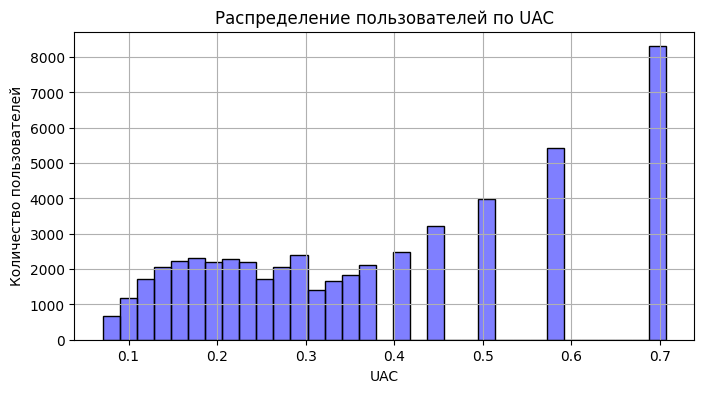

In [15]:
# Средний рейтинг и количество оценок
user_features = ratings.groupby('user_id').agg(
        user_avg_rating=('rating', 'mean'),
        user_rating_count=('book_id', 'count')
    ).reset_index()

# Активность пользователя
# Формула UAC -> 1/sqrt(d1 * d2), только для одного пользователя
user_features['user_activity_count'] = 1 / np.sqrt(user_features['user_rating_count'])

plt.figure(figsize=(8, 4))
hist = sns.histplot(user_features, x='user_activity_count', color='blue', alpha=0.5)
hist.set_title('Распределение пользователей по UAC')
hist.set_xlabel('UAC')
hist.set_ylabel('Количество пользователей')
hist.grid()

In [16]:
user_features.head()

,user_id,user_avg_rating,user_rating_count,user_activity_count
0,1,3.666667,3,0.577350
1,2,4.333333,3,0.577350
2,3,1.000000,2,0.707107
3,4,4.000000,3,0.577350
4,5,4.200000,5,0.447214


#### Признаки книг: популярность, разнообразие оценок, тематические категории.

In [17]:
# Популярность книги -> взвешенный рейтинг
books_popularity = books[['work_ratings_count', 'work_text_reviews_count']]

# Нормализуем данные, так как шкалы разные
books_popularity['pop_log_ratings'] = np.log1p(books_popularity['work_ratings_count'])
books_popularity['pop_log_reviews'] = np.log1p(books_popularity['work_text_reviews_count'])
# Смешиваем: 70% веса количеству оценок, 30% текстовым отзывам
books_popularity['popularity_index'] = (books_popularity['pop_log_ratings'] * 0.7) + (books_popularity['pop_log_reviews'] * 0.3)
books_popularity = books_popularity.drop(['work_ratings_count', 'work_text_reviews_count', 'pop_log_ratings', 'pop_log_reviews'], axis=1)
books_popularity = books_popularity.reset_index(drop=True)

In [18]:
# Разнообразие оценок
# Чем выше энтропия, тем выше разнообразие
def entrophy_calc(row):
    '''Вычисляет энтропию Шеннона по количеству
    выставленных оценок каждого типа'''
    count = row[['ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5']]    
    total = np.sum(count)
    probs = count / total    
    probs_fl = np.array([float(x) for x in probs])    
    return -np.sum(probs_fl * np.log2(probs_fl))    

books_diversity = books.apply(entrophy_calc, axis=1)
books_diversity = books_diversity.reset_index(drop=True)

In [19]:
books_features = pd.concat([books_popularity, pd.Series(books_diversity, name='books_diversity')], axis=1)
books_features.head()

,popularity_index,books_diversity
0,14.375196,1.573085
1,14.139923,1.450875
2,14.065076,2.193653
3,13.872987,1.677672
4,13.642656,1.964913


In [20]:
np.random.seed(42)
# Тематические категории -> BERTopic
all_stop_words = set()
for lang in stopwords.fileids():
    all_stop_words.update(stopwords.words(lang))

def remove_stopwords(text):
    '''Убирает стоп-слова и пунктуацию из текста'''
    tokens = word_tokenize(text.lower())    
    tokens = [word for word in tokens if word not in all_stop_words and word not in string.punctuation]
    return ' '.join(tokens)

docs = books['original_title'].apply(remove_stopwords)
bert_model = BERTopic()
topics, probs = bert_model.fit_transform(docs)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 826.40it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
topics_info = bert_model.get_topic_info()
display(topics_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2195,-1_vol_club_things_guide,"[vol, club, things, guide, holmes, sherlock, r...","[strange case dr jekyll mr hyde, transmetropol..."
1,0,427,0_amor_storia_histoire_geschichte,"[amor, storia, histoire, geschichte, lngstrump...","[flickan lekte elden, cien sonetos amor, amor ..."
2,1,137,1_god_jesus_gods_preacher,"[god, jesus, gods, preacher, faith, antichrist...","[gods, jesus stories, jesus freaks dc talk voi..."
3,2,123,2_desu_nto_ichikyhachiyon_bleach,"[desu, nto, ichikyhachiyon, bleach, 1q84, dans...","[デスノート 3 desu nōto gekisō 激走, デスノート 2 desu nōt..."
4,3,111,3_scarlet_alice_elizabeth_mary,"[scarlet, alice, elizabeth, mary, miss, duches...","[alice, scarlet, scarlet]"
5,4,77,4_death_grief_dying_observed,"[death, grief, dying, observed, unnatural, por...","[born death death 23, death, death dying]"
6,5,75,5_darkness_darkest_dark_kiss,"[darkness, darkest, dark, kiss, underworld, lo...","[darkest kiss, darkness night, darkness]"
7,6,75,6_house_home_room_welcome,"[house, home, room, welcome, long, kitchen, ho...","[house, house, house]"
8,7,67,7_bird_silver_swan_pigeon,"[bird, silver, swan, pigeon, birds, whale, haw...","[silver chair, black bird volume 1, talon silv..."
9,8,64,8_sun_stars_rama_star,"[sun, stars, rama, star, sunset, suns, sunshin...","[city stars, stars, sun star]"


In [22]:
print('books shape', books.shape)
print('len topics', len(topics))

books shape (7860, 21)
len topics 7860


In [23]:
# формируем признаки тем
book_topic = pd.concat([
                        books['book_id'].reset_index(drop=True),
                        pd.Series(topics, name='topic_id')
                                                        ], axis=1)
def get_embedding(topic_id):    
    return bert_model.topic_embeddings_[topic_id]

book_topic['topic_embedding'] = book_topic['topic_id'].apply(get_embedding)

In [24]:
books_features = pd.concat([books_features, book_topic], axis=1)
books_features.head()

,popularity_index,books_diversity,book_id,topic_id,topic_embedding
0,14.375196,1.573085,2767052,160,"[-0.039553974, 0.031627268, -0.01697191, 0.021..."
1,14.139923,1.450875,3,91,"[-0.059816375, -0.026098024, 0.0003583344, 0.0..."
2,14.065076,2.193653,41865,137,"[-0.055452425, 0.04367121, 0.0010087634, 0.044..."
3,13.872987,1.677672,2657,-1,"[-0.041829612, 0.04813596, 0.00518408, -0.0116..."
4,13.642656,1.964913,4671,80,"[-0.03025067, 0.041418236, 0.0408928, -0.02031..."


#### Признаки взаимодействий: схожесть с историей пользователя.

In [25]:
tqdm.pandas(desc='Группировка тегов')
gc.collect()

# Объединяем теги с их названиями
book_tags_joined = book_tags.merge(tags[['tag_id', 'tag_name']], on='tag_id')
# Группируем теги в строки (без раздувания, для экономии памяти)
book_descriptions = (
    book_tags_joined
    .groupby('goodreads_book_id')['tag_name']
    .progress_apply(lambda x: ' '.join(x.astype(str)))
    .reset_index(name='tag_str')
)
# Очистка памяти
del book_tags_joined 
gc.collect()

# Векторизация книг (Content Space)
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', dtype=np.float32)
item_vectors = tfidf.fit_transform(book_descriptions['tag_str'])
item_vectors = normalize(item_vectors)

# Маппинг: book_id в базе -> индекс строки в матрице item_vectors
book_id_to_idx = {id: i for i, id in enumerate(book_descriptions['goodreads_book_id'])}

# Создание профилей пользователей (User Profiles)
top_ratings = ratings[ratings['rating'] >= 4].copy()
# Оставляем только те книги, для которых у нас есть текстовое описание (теги)
top_ratings = top_ratings[top_ratings['book_id'].isin(book_id_to_idx)]

# фиксируем размерности
num_books = item_vectors.shape[0]           
num_users = ratings['user_id'].max() + 1      
rows = top_ratings['user_id'].values
cols = top_ratings['book_id'].map(book_id_to_idx).values
data = top_ratings['rating'].values

# Создаем разреженную матрицу User-Item 
user_item_matrix = csr_matrix((data, (rows, cols)), shape=(num_users, num_books))
# Считаем профили: перемножаем взаимодействия на признаки книг
user_profiles = user_item_matrix.dot(item_vectors)
user_profiles = normalize(user_profiles) 

# Функция для  расчета схожести 
def get_similarity_batch(user_ids, book_ids, user_profiles, item_vectors, book_id_to_idx):    
    # Получаем индексы книг (те, что не найдены, помечаем как -1)
    b_indices = np.array([book_id_to_idx.get(bid, -1) for bid in book_ids])    
    # Маска для существующих книг (чтобы избежать ошибок индексации)
    valid_mask = b_indices != -1    
    # Подготавливаем массив для результатов
    sims = np.zeros(len(user_ids))    
    if valid_mask.any():
        # Извлекаем векторы пользователей и книг только для валидных индексов
        u_vecs = user_profiles[user_ids[valid_mask]]
        b_vecs = item_vectors[b_indices[valid_mask]]        
        # Скалярное произведение нормализованных векторов (Cosine Similarity)        
        batch_sims = np.array(u_vecs.multiply(b_vecs).sum(axis=1)).flatten()
        sims[valid_mask] = batch_sims
        
    return sims

# Финальный расчет признака для всей таблицы ratings
ratings['history_similarity'] = get_similarity_batch(
    user_ids=ratings['user_id'].values,     
    book_ids=ratings['book_id'].values,    
    user_profiles=user_profiles,           
    item_vectors=item_vectors,            
    book_id_to_idx=book_id_to_idx          
)

gc.collect()

Группировка тегов: 100%|██████████| 10000/10000 [00:00<00:00, 16694.21it/s]


0

### Popularity Recommender

In [26]:
class PopularityRecommender:
    '''Модель рекоммендаций книг по популярности'''
    def __init__(self, threshold: float = 4.0):        
        self.threshold = threshold
        self.popular_books = None 
        
    def fit(self, books: pd.DataFrame):
        '''Отбирает книги с рейтингом выше порога'''
        self.popular_books = books[books['average_rating'] >= self.threshold].reset_index(drop=True)
        
    def recommend(self, user_id: int = None, k: int = 5,) -> pd.DataFrame:
        recs = self.popular_books[['book_id', 'authors', 'original_title', 'average_rating']].copy()
        sample_size = min(k, len(recs))
        recommendations = recs.sample(n=sample_size).reset_index(drop=True)
        return recommendations    

### Content Recommender

In [28]:
class ContentRecommender:
    '''Контентная модель рекоммендаций,
    основанная на косинусной близости'''
    def __init__(self):        
        self.tfidf_matrix = None
        self.vectorizer = None 
        self.books_with_features = None 
        
    def fit(self, books: pd.DataFrame, book_tags: pd.DataFrame, tags: pd.DataFrame, book_features: pd.DataFrame):
        '''Обучает модель: TfIdf векторизация и вычисление косинусной близости'''
        # Объединяем теги
        book_tags_names = book_tags.merge(tags[['tag_id', 'tag_name']], on='tag_id', how='left')
        book_to_tags = book_tags_names.groupby('goodreads_book_id')['tag_name'].apply(
            lambda x: ' '.join(x.astype(str))
        ).reset_index(name='tag_str')
        
        # Объединяем с книгами
        self.books_with_features = books[['book_id', 'authors', 'original_title']].merge(
            book_to_tags, left_on='book_id', right_on='goodreads_book_id', how='left'
        ).fillna('').drop('goodreads_book_id', axis=1)
        
        # Добавляем новые признаки
        self.books_with_features = self.books_with_features.merge(
            book_features[['book_id', 'topic_embedding', 'popularity_index', 'books_diversity', 'topic_id']],
            on='book_id', how='left'
        ).fillna(0)

          #  Создаем текстовый профиль
        self.books_with_features['profile'] = (
            self.books_with_features['original_title'] + ' ' +
            self.books_with_features['tag_str']
        )
        
        # Векторизация
        self.vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
        self.tfidf_matrix = self.vectorizer.fit_transform(self.books_with_features['profile'])
        
    def recommend(self, user_id: int, books_df: pd.DataFrame,
                  ratings_df: pd.DataFrame, book_tags: pd.DataFrame,
                  tags: pd.DataFrame, books_features_df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
        # Проверяем, обучена ли модель
        if self.books_with_features is None:
            print("ContentRecommender not fitted yet.")
            return pd.DataFrame(columns=['book_id', 'authors', 'original_title'])

        # Берем прочитанные пользователем книги
        user_ratings = ratings_df[ratings_df['user_id'] == user_id]
        user_read_books = user_ratings['book_id'].unique().tolist()
        if not user_read_books:
            # Если нет прочитанных книг, возвращаем популярные
            popular_books = books_df.nlargest(k, 'average_rating')
            return popular_books[['book_id', 'authors', 'original_title']].head(k)

        # Выбираем случайно одну
        selected_book_id = np.random.choice(user_read_books)
        # Находим индекс книги
        idx_series = self.books_with_features[self.books_with_features['book_id'] == selected_book_id].index
        if len(idx_series) == 0:
            # Если книга не найдена, возвращаем популярные
            popular_books = books_df.nlargest(k, 'average_rating')
            return popular_books[['book_id', 'authors', 'original_title']].head(k)
        idx = idx_series[0] # Получаем первый индекс

        # Считаем косинусное сходство        
        if idx >= self.tfidf_matrix.shape[0]:
            print(f"Warning: Index {idx} out of bounds for tfidf_matrix with shape {self.tfidf_matrix.shape}. Returning popular books.")
            popular_books = books_df.nlargest(k, 'average_rating')
            return popular_books[['book_id', 'authors', 'original_title']].head(k)

        # Извлекаем строку и вычисляем сходства
        single_row = self.tfidf_matrix[idx] 
        sim_scores_raw = cosine_similarity(single_row, self.tfidf_matrix)

        # Конвертируем в плотный ndarray и затем во flat 1D array      
        sim_scores_dense = np.asarray(sim_scores_raw).flatten()
        
        sim_scores_clean = np.nan_to_num(sim_scores_dense, nan=0.0, posinf=1.0, neginf=-1.0)

        # Исключаем саму книгу (idx) - устанавливаем её схожесть в -1 или 0, чтобы точно не выбрать
        sim_scores_clean[idx] = -2.0 # Устанавливаем заведомо низкое значение

        # Проверяем, что массив чисел
        if not np.issubdtype(sim_scores_clean.dtype, np.number):
             print("Warning: sim_scores_clean contains non-numeric data. Returning empty DataFrame.")
             return pd.DataFrame(columns=['book_id', 'authors', 'original_title'])

        # Сортируем индексы по убыванию значений схожести        
        top_indices = np.argsort(sim_scores_clean)[::-1][:k]

        # Возвращаем датафрейм с топ-K         
        return self.books_with_features.iloc[top_indices][['book_id', 'authors', 'original_title']]

### Item-Based Collaborative Filtering

In [29]:
class CFRecommender:
    '''Реализует Item-Based коллаборативную фильтрацию'''

    def __init__(self, use_implicit: bool = False):
        self.use_implicit = use_implicit # Использовать ли неявный фидбек       
        self.user_book_matrix = None
        self.book_similarity_matrix = None
        self.user_features = None
        self.book_features = None
        self.history_similarity = None
        self.books = None

    def fit(self, ratings: pd.DataFrame, books: pd.DataFrame, user_features: pd.DataFrame, book_features: pd.DataFrame):
        '''Обучает модель. Строит матрицы.'''
        self.books = books
        # Подготовка ratings
        if self.use_implicit:
            ratings = ratings.copy()
            ratings['rating'] = (ratings['rating'] >= 4).astype(int)
    
        # Уникальные id
        unique_users = ratings['user_id'].unique()
        unique_books = ratings['book_id'].unique()
    
        # Маппинг в индексы
        user_to_idx = {u: i for i, u in enumerate(unique_users)}
        book_to_idx = {b: i for i, b in enumerate(unique_books)}
    
        # Создание разреженной матрицы (Book x User)
        rows = ratings['book_id'].map(book_to_idx)
        cols = ratings['user_id'].map(user_to_idx)
        data = ratings['rating']
    
        user_book_sparse = csr_matrix((data, (rows, cols)), shape=(len(unique_books), len(unique_users)))
    
        # Сохраняем как обычную матрицу
        self.user_book_matrix = pd.DataFrame(
            user_book_sparse.toarray(),
            index=unique_books,
            columns=unique_users
        )
    
        # Матрица схожести книг (косинусная близость)
        book_similarity = cosine_similarity(user_book_sparse)
        self.book_similarity_matrix = pd.DataFrame(
            book_similarity,
            index=unique_books,
            columns=unique_books
        )
    
        # Сохраняем признаки
        self.user_features = user_features.set_index('user_id')[['user_avg_rating', 'user_rating_count', 'user_activity_count']]
        self.book_features = book_features.set_index('book_id')[['popularity_index', 'books_diversity', 'topic_embedding']]
        self.history_similarity = ratings.set_index(['user_id', 'book_id'])['history_similarity']

    def predict_rating(self, user_id: int, book_id: int) -> float:
        '''Предсказывает оценку'''
        if book_id not in self.book_similarity_matrix.index or user_id not in self.user_book_matrix.columns:
            return 0.0

        # Схожесть с book_id
        similarities = self.book_similarity_matrix.loc[book_id]
        user_ratings = self.user_book_matrix[user_id]

        # Оставляем только оцененные книги
        rated_books = user_ratings[user_ratings > 0].index
        # Берем только k самых похожих книг из оцененных
        similar_books = similarities[rated_books].sort_values(ascending=False)

        # Взвешенное усреднение
        numerator = 0.0
        denominator = 0.0
        for b, sim in similar_books.items():
            numerator += sim * user_ratings[b]
            denominator += abs(sim)

        return numerator / denominator if denominator > 0 else 0.0

    def recommend(self, user_id: int, k: int = 5) -> pd.DataFrame:
        '''Возвращает топ-K рекомендованных книг для пользователя в виде DataFrame'''      
        
        if user_id not in self.user_book_matrix.columns:
            # Если пользователя нет, возвращаем популярные книги
            if hasattr(self, 'books') and self.books is not None:
                popular_books = self.books.nlargest(k, 'average_rating')
                return popular_books[['book_id', 'authors', 'original_title', 'average_rating']].head(k)
            else:
                return pd.DataFrame(columns=['book_id', 'authors', 'original_title', 'average_rating'])
        
        user_ratings = self.user_book_matrix[user_id] # Книги, которые пользователь оценил
        unrated_books = user_ratings[user_ratings == 0].index # Книги, которые пользователь не оценил
        
        if len(unrated_books) == 0:
            print('Нет непрочитанных книг для пользователя')           
            if hasattr(self, 'books') and self.books is not None:
                popular_books = self.books.nlargest(k, 'average_rating')
                return popular_books[['book_id', 'authors', 'original_title', 'average_rating']].head(k)
            else:
                return pd.DataFrame(columns=['book_id', 'authors', 'original_title', 'average_rating'])
        
        # Предсказание оценок для непрочитанных книг
        predictions = [] 
        for book_id in unrated_books:
            pred = self.predict_rating(user_id, book_id) 
            predictions.append((book_id, pred))
            
        # Сортируем оценки по убыванию
        predictions.sort(key=lambda x: x[1], reverse=True)
        
        # Фильтруем, чтобы брать только книги, которые есть в books_df
        if hasattr(self, 'books') and self.books is not None:
            all_available_books = set(self.books['book_id'].values)
            top_k_filtered = [(book_id, score) for book_id, score in predictions if book_id in all_available_books]
        else:
            top_k_filtered = predictions
        
        # Выбираем топ-k книг
        top_k_books = [x[0] for x in top_k_filtered[:k]]
       
        # Фильруем датафрейм с информацией о книгах по id
        if hasattr(self, 'books') and self.books is not None and top_k_books:
            recommended = self.books[self.books['book_id'].isin(top_k_books)]
            # Сортируем по порядку 
            recommended = recommended.set_index('book_id').loc[top_k_books].reset_index()
        else:
            # Если нет книг, возвращаем пустой датафрейм
            recommended = pd.DataFrame(columns=['book_id', 'authors', 'original_title', 'average_rating'])
            
        return recommended[['book_id', 'authors', 'original_title', 'average_rating']]

### SVD Recommender

In [30]:
class SVDRecommender:
    '''Реализует SVD рекомендации'''
    def __init__(self, n_factors: int = 100, n_epochs: int = 100, lr_all: float = 0.007, random_state: int = 42):        
        self.SVD = SVD  # Сохраняем класс для использования
        self.model = SVD(n_factors=n_factors, n_epochs=n_epochs, lr_all=lr_all, random_state=random_state)
        self.reader = Reader(rating_scale=(1, 5))
        self.trainset = None
        self.user_features = None
        self.book_features = None
        self.history_similarity = None        

    def fit(self, ratings: pd.DataFrame, user_features: pd.DataFrame, book_features: pd.DataFrame):
        '''Обучает модель с признаками'''        
        # Сохраняем признаки
        self.user_features = user_features.set_index('user_id')[['user_avg_rating', 'user_rating_count', 'user_activity_count']]
        self.book_features = book_features.set_index('book_id')[['popularity_index', 'books_diversity', 'topic_embedding']]
        self.history_similarity = ratings.set_index(['user_id', 'book_id'])['history_similarity']

        # Подготовка данных для Surprise
        data = Dataset.load_from_df(ratings[['user_id', 'book_id', 'rating']], self.reader)
        self.trainset = data.build_full_trainset()
        self.model.fit(self.trainset)

    def recommend(self, user_id: int, books_df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
        '''Рекомендует книги'''        
        # Проверяем, известен ли пользователь
        try:
            inner_id = self.trainset.to_inner_uid(user_id)
        except ValueError:
            # Пользователь неизвестен, возвращаем популярные книги
            popular_books = books_df.nlargest(k, 'average_rating')
            return popular_books[['book_id', 'authors', 'original_title', 'average_rating']].head(k)

        # Все книги, доступные в books_df
        all_books = set(books_df['book_id'].values)
        # Книги, которые пользователь уже оценил
        user_items = set([self.trainset.to_raw_iid(i) for i, _ in self.trainset.ur[inner_id]])
        # Книги, которые пользователь не оценил
        unrated_books = list(all_books - user_items)

        # Предсказания
        predictions = [
            (book_id, self.model.predict(user_id, book_id).est)
            for book_id in unrated_books[:min(1000, len(unrated_books))]  # ограничиваем для производительности
        ]
        predictions.sort(key=lambda x: x[1], reverse=True)

        # Топ-K
        top_k_books = [x[0] for x in predictions[:k]]
        if not top_k_books:
            # Если нет рекомендаций, возвращаем популярные
            popular_books = books_df.nlargest(k, 'average_rating')
            return popular_books[['book_id', 'authors', 'original_title', 'average_rating']].head(k)

        recommendations = books_df[books_df['book_id'].isin(top_k_books)]
        recommendations = recommendations.set_index('book_id').loc[top_k_books].reset_index()

        return recommendations[['book_id', 'authors', 'original_title', 'average_rating']]

### Hybrid Recommender

In [31]:
class HybridRecommender:
    '''Гибридная система рекомендаций'''
    def __init__(self, popularity_model, content_model, cf_model, svd_model):
        self.popularity_model = popularity_model
        self.content_model = content_model
        self.cf_model = cf_model
        self.svd_model = svd_model

    def recommend(self, user_id: int, books_df: pd.DataFrame, ratings_df: pd.DataFrame, 
                  book_tags: pd.DataFrame, tags: pd.DataFrame, books_features: pd.DataFrame,
                  user_features: pd.DataFrame, k: int = 5):
        '''Генерирует рекомендации для пользователя'''
        # Считаем, сколько книг оценил пользователь 
        user_ratings = ratings_df[ratings_df['user_id'] == user_id]
        n_ratings = user_ratings['book_id'].nunique()

        # Если мало оценок — используем популярность
        if n_ratings < 5:
            self.popularity_model.fit(books_df)
            print(f'Popularity Model for user {user_id} (ratings: {n_ratings})')
            return self.popularity_model.recommend(user_id, k=k)
        
        # Если оценок от 5 до 100 - контентная модель
        # if 5 <= n_ratings < 100:
        #     # Берем прочитанные пользователем книги
        #     user_read_books = user_ratings['book_id'].unique().tolist()
            
        #     if not user_read_books:
        #         self.popularity_model.fit(books_df)
        #         return self.popularity_model.recommend(user_id, k=k)
                
        #     # Выбираем случайно одну            
        #     selected_book_id = np.random.choice(user_read_books)
            
        #     # Обучаем контентную модель (если она еще не обучена)
        #     if not hasattr(self.content_model, 'books_with_features') or self.content_model.books_with_features is None:
        #         self.content_model.fit(books_df, book_tags, tags, books_features)  
            
        #     print(f'Content Model for user {user_id} (ratings: {n_ratings})')
        #     # Используем выбранную книгу для получения похожих
        #     try:
        #         similar_recs = self.content_model.recommend(user_id, books, ratings, book_tags, tags, books_features, k=5)
        #         if similar_recs is not None and not similar_recs.empty:
        #             return similar_recs[['book_id', 'authors', 'original_title']].head(k)
        #         else:
        #             # Если не удалось найти похожие, возвращаем популярные
        #             self.popularity_model.fit(books_df)
        #             return self.popularity_model.recommend(user_id, k=k)
        #     except Exception as e:
        #         print(f"Error in content model: {e}")
        #         self.popularity_model.fit(books_df)
        #         return self.popularity_model.recommend(user_id, k=k)
        else:
        # Если оценок >= 5 - используем коллаборативные фильтры
            try:
                # Обучаем модели
                self.cf_model.fit(ratings_df, books_df, user_features, books_features)
                self.svd_model.fit(ratings_df, user_features, books_features)
    
                # Берем прочитанные пользователем книги для контентной модели
                user_read_books = user_ratings['book_id'].unique().tolist()
                
                selected_book_id = np.random.choice(user_read_books) if user_read_books else None
                
                # cont_recs = pd.DataFrame()  # пустой датафрейм
                # if selected_book_id:
                #     cont_recs = self.content_model.recommend(selected_book_id, k)
                
                cf_recs = self.cf_model.recommend(user_id, k=k)
                svd_recs = self.svd_model.recommend(user_id, books_df, k=k)
    
                # Взвешенное объединение 
                combined_scores = {}
                
                # Добавляем оценки от контентной модели
                # if cont_recs is not None and not cont_recs.empty:
                #     for _, row in cont_recs.iterrows():
                #         book_id = row['book_id']
                #         combined_scores[book_id] = combined_scores.get(book_id, 0) + 0.1
                
                # Добавляем оценки от CF модели
                if cf_recs is not None and not cf_recs.empty:
                    for _, row in cf_recs.iterrows():
                        book_id = row['book_id']
                        combined_scores[book_id] = combined_scores.get(book_id, 0) * 0.2
                
                # Добавляем оценки от SVD модели
                if svd_recs is not None and not svd_recs.empty:
                    for _, row in svd_recs.iterrows():
                        book_id = row['book_id']
                        combined_scores[book_id] = combined_scores.get(book_id, 0) * 0.5
    
                # Сортируем и возвращаем топ-K
                if combined_scores:
                    top_books = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)[:k]
                    top_book_ids = [x[0] for x in top_books]
    
                    if top_book_ids:
                        recommendations = books_df[books_df['book_id'].isin(top_book_ids)]
                        recommendations = recommendations.set_index('book_id').loc[top_book_ids].reset_index()
                        return recommendations[['authors', 'original_title', 'book_id']].rename(columns={'book_id': 'book_id'})
            
            except Exception as e:
                print(f"Error in collaborative models: {e}")
            
            # Если что-то пошло не так, возвращаем популярные
            self.popularity_model.fit(books_df)
            return self.popularity_model.recommend(user_id, k=k)

In [32]:
pop_model = PopularityRecommender()
content_model = ContentRecommender()
cf_model = CFRecommender()
svd_model = SVDRecommender()
hybrid_model = HybridRecommender(pop_model, content_model, cf_model, svd_model)

### Оценка моделей

In [33]:
class ModelEvaluator:
    """Класс для оценки качества рекомендательных моделей."""

    def __init__(self, k: int = 5, threshold: float = 4.0):
        """
        :param k: количество рекомендаций для оценки
        :param threshold: порог релевантности (если rating >= threshold, то релевантно)
        """
        self.k = k
        self.threshold = threshold

    def precision_at_k(self, y_true: list[float], y_pred: list[float]) -> float:
        """Precision@K: доля релевантных рекомендаций среди top-K."""
        top_k_pred = y_pred[:self.k]
        relevant_count = sum(1 for rating in top_k_pred if rating >= self.threshold)
        return relevant_count / len(top_k_pred) if top_k_pred else 0.0

    def recall_at_k(self, y_true: list[float], y_pred: list[float]) -> float:
        """Recall@K: доля релевантных рекомендаций среди всех релевантных."""
        relevant_true = [rating for rating in y_true if rating >= self.threshold]
        if not relevant_true:
            return 0.0

        top_k_pred = y_pred[:self.k]
        relevant_in_pred = sum(1 for rating in top_k_pred if rating >= self.threshold)

        return relevant_in_pred / len(relevant_true)

    def dcg_at_k(self, y_true: list[float], y_pred: list[float]) -> float:
        """Discounted Cumulative Gain@K."""
        top_k_pred = y_pred[:self.k]
        relevance = [1.0 if rating >= self.threshold else 0.0 for rating in top_k_pred]
        dcg = relevance[0] if relevance else 0.0
        for i in range(1, len(relevance)):
            dcg += relevance[i] / np.log2(i + 1)
        return dcg

    def idcg_at_k(self, y_true: list[float]) -> float:
        """Ideal Discounted Cumulative Gain@K."""
        relevance = [1.0 if rating >= self.threshold else 0.0 for rating in y_true]
        relevance.sort(reverse=True)
        relevance = relevance[:self.k]
        idcg = relevance[0] if relevance else 0.0
        for i in range(1, len(relevance)):
            idcg += relevance[i] / np.log2(i + 1)
        return idcg

    def ndcg_at_k(self, y_true: list[float], y_pred: list[float]) -> float:
        """Normalized Discounted Cumulative Gain@K."""
        dcg = self.dcg_at_k(y_true, y_pred)
        idcg = self.idcg_at_k(y_true)
        return dcg / idcg if idcg > 0 else 0.0
      
    def evaluate_user(self, user_id: int, model, test_ratings: pd.DataFrame,
                      books_df: pd.DataFrame, ratings_df: pd.DataFrame = None,
                      book_tags: pd.DataFrame = None, tags: pd.DataFrame = None,
                      books_features: pd.DataFrame = None, user_features: pd.DataFrame = None) -> dict[str, float]:
        # Реальные оценки пользователя
        user_true = test_ratings[test_ratings['user_id'] == user_id]
        true_ratings_map = user_true.set_index('book_id')['rating'].to_dict()
        y_true = list(true_ratings_map.values())

        # Проверяем тип модели
        if isinstance(model, PopularityRecommender):
            # У популярности нет зависимости от пользователя
            recommendations = model.recommend(k=self.k)
        elif isinstance(model, HybridRecommender):
            # У гибридной модели много аргументов
            recommendations = model.recommend(user_id, books_df, ratings_df, book_tags, tags, books_features, user_features, k=self.k)
        elif isinstance(model, ContentRecommender):
            recommendations = model.recommend(user_id, books_df, ratings_df, book_tags, tags, books_features, k=self.k)
        elif isinstance(model, CFRecommender):
            # У коллаборативной модели есть свои аргументы
            # Она принимает только user_id и k
            recommendations = model.recommend(user_id, k=self.k) # <-- ИСПРАВЛЕНО
        else:
            # Для всех остальных моделей (например, SVD)
            try:
                recommendations = model.recommend(user_id, books_df, k=self.k)
            except TypeError:
                # Если не получилось, вызываем с user_id, k
                recommendations = model.recommend(user_id, k=self.k)

        predicted_book_ids = recommendations['book_id'].tolist()
        y_pred = [true_ratings_map.get(book_id, 0.0) for book_id in predicted_book_ids]

        return {
            'precision@k': self.precision_at_k(y_true, y_pred),
            'recall@k': self.recall_at_k(y_true, y_pred),
            'ndcg@k': self.ndcg_at_k(y_true, y_pred)
        }

    def evaluate(self, model, test_ratings: pd.DataFrame, books_df: pd.DataFrame,
                 ratings_df: pd.DataFrame, book_tags: pd.DataFrame, tags: pd.DataFrame,
                 books_features: pd.DataFrame, user_features: pd.DataFrame) -> dict[str, float]:
        """
        Вычисляет средние метрики по всем пользователям в тесте.
        :param model: модель с методом recommend
        :param test_ratings: датафрейм с тестовыми оценками
        :param books_df: датафрейм с информацией о книгах
        :param ratings_df: датафрейм с оценками (для гибридной модели)
        :param book_tags: датафрейм с тегами книг
        :param tags: датафрейм с названиями тегов
        :param books_features: датафрейм с признаками книг
        :param user_features: датафрейм с признаками пользователей
        :return: словарь со средними метриками
        """
        user_ids = test_ratings['user_id'].unique()
        results = []

        for user_id in user_ids:
            user_metrics = self.evaluate_user(user_id, model, test_ratings, books_df, ratings_df, book_tags, tags, books_features, user_features)
            results.append(user_metrics)

        # Средние значения
        avg_metrics = {
            'precision@k': np.mean([r['precision@k'] for r in results]),
            'recall@k': np.mean([r['recall@k'] for r in results]),
            'ndcg@k': np.mean([r['ndcg@k'] for r in results])
        }
        return avg_metrics

evaluator = ModelEvaluator(k=5, threshold=4.0)

In [35]:
SAMPLE = 30 # Размер выборки для подсчета метрик

In [36]:
pop_model.fit(books)
metrics_pop = evaluator.evaluate(pop_model, cold_ratings, books, ratings, book_tags, tags, books_features, user_features)
print(f"Popularity model: {metrics_pop} \n")

Popularity model: {'precision@k': 1.1290504685559445e-05, 'recall@k': 1.881750780926574e-05, 'ndcg@k': 9.241135553481414e-06} 



In [37]:
cf_model.fit(ratings, books, user_features, books_features)
metrics_cf = evaluator.evaluate(cf_model, test_df.sample(SAMPLE), books, ratings, book_tags, tags, books_features, user_features)
print(f"CF model: {metrics_cf} \n")

CF model: {'precision@k': 0.0, 'recall@k': 0.0, 'ndcg@k': 0.0} 



In [38]:
svd_model.fit(ratings, user_features, books_features)
metrics_svd = evaluator.evaluate(svd_model, test_df.sample(SAMPLE), books, ratings, book_tags, tags, books_features, user_features)
print(f"SVD model: {metrics_svd} \n")

SVD model: {'precision@k': 0.0, 'recall@k': 0.0, 'ndcg@k': 0.0} 



In [ ]:
hybrid_metrics = evaluator.evaluate(hybrid_model, test_df.sample(SAMPLE), books, ratings, book_tags, tags, books_features, user_features)
print(f"Hybrid model: {hybrid_metrics} \n")

In [ ]:
metrics = pd.concat([
pd.Series(metrics_pop, name="Popularity"),
pd.Series(metrics_cf, name="CF"),
pd.Series(metrics_svd, name="SVD"),
pd.Series(hybrid_metrics, name="Hybrid")
], axis=1)
metrics

,Popularity,CF,SVD,Hybrid
precision@k,0.000023,0.0,0.0,0.0
recall@k,0.000047,0.0,0.0,0.0
ndcg@k,0.000050,0.0,0.0,0.0


+ Все модели показывают крайне низкие значения метрик. Все значения близки к 0, что указывает на то, что рекомендации, генерируемые моделями, практически не соответствуют тестовым данным. Модели не угадывают, какие книги пользователь оценит высоко.
+ Модель популярности (Popularity), хотя и имеет самые высокие метрики, также неэффективна. Это означает, что просто рекомендовать популярные книги не работает для точного предсказания интересов конкретного пользователя на основе тестового набора.
Коллаборативные фильтры (CF, SVD) и гибридная модель показали идеальные нули. Это может свидетельствовать о следующих проблемах:
    + Проблемы с обучением: Модели могли не обучиться полезным паттернам из-за разреженности данных, некорректной предобработки или ошибок в реализации алгоритмов.
    + Проблемы с разреженностью: Если у пользователей в тесте очень мало оценок, или эти оценки не пересекаются с теми, которые модели могут предсказать, метрики будут близки к нулю.
    Ошибка в evaluate_user: Для CFRecommender, SVD, и Hybrid может не находиться пересечение между recommended['book_id'] и true_ratings_map.keys(), приводя к пустому y_pred или y_pred с нулями, что даст precision, recall, и ndcg, равные 0.

## **Wide & Deep**

In [ ]:
# Подготовка данных 
# Объединяем рейтинги с признаками
data = ratings.merge(user_features, on='user_id', how='inner') \
              .merge(books_features, on='book_id', how='inner') \
              .merge(books[['book_id', 'original_title', 'authors']], on='book_id', how='inner')

THRESHOLD = 4.0
data['high_rating'] = (data['rating'] >= THRESHOLD).astype(int)

print(f"Общее количество записей: {len(data)}")

# Кодирование ID
user_encoder = LabelEncoder()
book_encoder = LabelEncoder()
data['user_idx'] = user_encoder.fit_transform(data['user_id'])
data['book_idx'] = book_encoder.fit_transform(data['book_id'])

# Разделение данных
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
print(f"Размер обучающей выборки: {len(train_data)}")
print(f"Размер тестовой выборки: {len(test_data)}")

# Подготовка признаков
# Wide признаки (линейная часть)
wide_features = ['user_activity_count', 'popularity_index']
X_wide_train_np = train_data[wide_features].values.astype(np.float32)
X_wide_test_np = test_data[wide_features].values.astype(np.float32)

# Категориальные признаки для Deep части
deep_categorical_features = {
    'user_idx': data['user_idx'].max() + 1,
    'book_idx': data['book_idx'].max() + 1
}

# Числовые признаки для Deep части
deep_numerical_features = ['user_avg_rating', 'user_rating_count', 'popularity_index', 'books_diversity']
scaler_deep = StandardScaler()
X_deep_num_train_np = scaler_deep.fit_transform(train_data[deep_numerical_features]).astype(np.float32)
X_deep_num_test_np = scaler_deep.transform(test_data[deep_numerical_features]).astype(np.float32)

# Целевая переменная
y_train_np = train_data['high_rating'].values.astype(np.float32)
y_test_np = test_data['high_rating'].values.astype(np.float32)

# PyTorch Dataset 
class WideDeepDataset(Dataset):
    def __init__(self, X_wide, X_deep_cat, X_deep_num, y):
        self.X_wide = torch.from_numpy(X_wide)
        self.X_deep_cat = {name: torch.LongTensor(df[name].values) for name, df in zip(deep_categorical_features.keys(), [X_deep_cat]*len(deep_categorical_features))}
        self.X_deep_num = torch.from_numpy(X_deep_num)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Возвращаем словарь признаков 
        return {
            'wide': self.X_wide[idx],
            'deep_cat': {name: self.X_deep_cat[name][idx] for name in self.X_deep_cat},
            'deep_num': self.X_deep_num[idx],
            'target': self.y[idx]
        }

# Подготовка данных для датасета
X_deep_cat_train = train_data[['user_idx', 'book_idx']]
X_deep_cat_test = test_data[['user_idx', 'book_idx']]

train_dataset = WideDeepDataset(X_wide_train_np, X_deep_cat_train, X_deep_num_train_np, y_train_np)
test_dataset = WideDeepDataset(X_wide_test_np, X_deep_cat_test, X_deep_num_test_np, y_test_np)

# PyTorch Wide & Deep Model
class WideDeepModel(nn.Module):
    def __init__(self, wide_dim, deep_categorical_dims, deep_numerical_dim, embedding_dim=8, deep_hidden_units=[128, 64]):
        super(WideDeepModel, self).__init__()

        # Wide часть (линейная)
        self.wide_linear = nn.Linear(wide_dim, 1)

        # Deep часть (эмбеддинги + MLP)
        self.embeddings = nn.ModuleDict()
        total_embedded_dim = 0
        for name, vocab_size in deep_categorical_dims.items():
            embed_dim = min(embedding_dim, (vocab_size + 1) // 2)
            self.embeddings[name] = nn.Embedding(vocab_size, embed_dim)
            total_embedded_dim += embed_dim

        # MLP после объединения эмбеддингов и числовых признаков
        mlp_input_dim = total_embedded_dim + deep_numerical_dim
        layers = []
        prev_dim = mlp_input_dim
        for units in deep_hidden_units:
            layers.append(nn.Linear(prev_dim, units))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_dim = units
        layers.append(nn.Linear(prev_dim, 1)) # Выходной слой для Deep части
        self.deep_mlp = nn.Sequential(*layers)

        # Финальный линейный слой для объединения Wide и Deep
        self.output_layer = nn.Linear(2, 1) # 2 потому что Wide и Deep выходят (1, 1)

    def forward(self, wide_input, deep_cat_inputs, deep_num_input):
        # Wide часть
        wide_out = self.wide_linear(wide_input)

        # Deep часть
        embedded_inputs = []
        for name, indices in deep_cat_inputs.items():
            embedded_inputs.append(self.embeddings[name](indices))
        embedded_concat = torch.cat(embedded_inputs, dim=1)
        deep_input_combined = torch.cat([embedded_concat, deep_num_input], dim=1)
        deep_out = self.deep_mlp(deep_input_combined)

        # Объединение Wide и Deep (как в статье: сумма, но мы используем MLP)
        combined_input = torch.cat([wide_out, deep_out], dim=1)
        output = self.output_layer(combined_input)

        # Применяем сигмоиду для вероятности
        return torch.sigmoid(output.squeeze(-1)) # Убираем последнюю размерность (batch, 1) -> (batch,)


# Обучение 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

BATCH_SIZE = 512
NUM_EPOCHS = 100
LEARNING_RATE = 0.001

model = WideDeepModel(
    wide_dim=len(wide_features),
    deep_categorical_dims=deep_categorical_features,
    deep_numerical_dim=len(deep_numerical_features),
    embedding_dim=8,
    deep_hidden_units=[128, 64]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCELoss() # Для бинарной классификации

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

best_val_loss = float('inf')
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        wide_batch = batch['wide'].to(device)
        deep_cat_batch = {k: v.to(device) for k, v in batch['deep_cat'].items()}
        deep_num_batch = batch['deep_num'].to(device)
        target_batch = batch['target'].to(device)

        optimizer.zero_grad()
        logits = model(wide_batch, deep_cat_batch, deep_num_batch)
        loss = criterion(logits, target_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    val_loss = 0
    all_targets = []
    all_predictions = []
    with torch.no_grad():
        for batch in test_loader:
            wide_batch = batch['wide'].to(device)
            deep_cat_batch = {k: v.to(device) for k, v in batch['deep_cat'].items()}
            deep_num_batch = batch['deep_num'].to(device)
            target_batch = batch['target'].to(device)

            logits = model(wide_batch, deep_cat_batch, deep_num_batch)
            loss = criterion(logits, target_batch)
            val_loss += loss.item()

            all_targets.extend(target_batch.cpu().numpy())
            all_predictions.extend(logits.cpu().numpy())

    avg_train_loss = total_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    auc = roc_auc_score(all_targets, all_predictions)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val AUC: {auc:.4f}')

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_widedeep_model_pytorch.pth')

# Оценка 
model.load_state_dict(torch.load('best_widedeep_model_pytorch.pth', map_location=device))
model.eval()

all_test_targets = []
all_test_predictions = []
with torch.no_grad():
    for batch in test_loader:
        wide_batch = batch['wide'].to(device)
        deep_cat_batch = {k: v.to(device) for k, v in batch['deep_cat'].items()}
        deep_num_batch = batch['deep_num'].to(device)
        target_batch = batch['target'].to(device)

        logits = model(wide_batch, deep_cat_batch, deep_num_batch)
        all_test_targets.extend(target_batch.cpu().numpy())
        all_test_predictions.extend(logits.cpu().numpy())

final_auc = roc_auc_score(all_test_targets, all_test_predictions)
final_logloss = log_loss(all_test_targets, all_test_predictions)
final_precision = precision_score(all_test_targets, (np.array(all_test_predictions) > 0.5).astype(int))

print(f"\n--- Итоговая оценка модели ---")
print(f"Test AUC: {final_auc:.4f}")
print(f"Test LogLoss: {final_logloss:.4f}")
print(f"Test Precision: {final_precision:.4f}")

Общее количество записей: 66324
Размер обучающей выборки: 53059
Размер тестовой выборки: 13265
Используем устройство: cpu
Epoch 1/100, Train Loss: 0.6378, Val Loss: 0.5724, Val AUC: 0.7604
Epoch 2/100, Train Loss: 0.5424, Val Loss: 0.5302, Val AUC: 0.7714
Epoch 3/100, Train Loss: 0.5314, Val Loss: 0.5275, Val AUC: 0.7736
Epoch 4/100, Train Loss: 0.5291, Val Loss: 0.5260, Val AUC: 0.7747
Epoch 5/100, Train Loss: 0.5255, Val Loss: 0.5249, Val AUC: 0.7751
Epoch 6/100, Train Loss: 0.5231, Val Loss: 0.5246, Val AUC: 0.7759
Epoch 7/100, Train Loss: 0.5197, Val Loss: 0.5229, Val AUC: 0.7771
Epoch 8/100, Train Loss: 0.5173, Val Loss: 0.5223, Val AUC: 0.7777
Epoch 9/100, Train Loss: 0.5140, Val Loss: 0.5215, Val AUC: 0.7784
Epoch 10/100, Train Loss: 0.5095, Val Loss: 0.5209, Val AUC: 0.7793
Epoch 11/100, Train Loss: 0.5044, Val Loss: 0.5224, Val AUC: 0.7781
Epoch 12/100, Train Loss: 0.4996, Val Loss: 0.5234, Val AUC: 0.7787
Epoch 13/100, Train Loss: 0.4954, Val Loss: 0.5245, Val AUC: 0.7768
Epo

In [ ]:
def get_recommendations_for_user(user_id, model, data, test_data, train_data,
                                user_encoder, book_encoder, scaler_deep,
                                wide_features, deep_numerical_features,
                                top_k=5, device=torch.device('cpu')):
    """
    Генерирует топ-K рекомендаций книг для заданного пользователя.
    Args:
        user_id: ID пользователя (исходный ID, не индекс).
        model: Обученная PyTorch модель Wide & Deep.
        data: Полный датафрейм (для получения признаков книг).
        test_data: Тестовый датафрейм.
        train_data: Тренировочный датафрейм.
        user_encoder: Обученный LabelEncoder для user_id.
        book_encoder: Обученный LabelEncoder для book_id.
        scaler_deep: Обученный StandardScaler для Deep числовых признаков.
        wide_features: Список названий признаков для Wide части.                      
        deep_numerical_features: Список названий числовых признаков для Deep части.
        top_k: Количество рекомендаций.
        device: Устройство PyTorch.
    Returns:
        DataFrame с топ-K рекомендованными книгами (book_id, original_title, authors, predicted_probability).
    """
    try:
        user_idx = user_encoder.transform([user_id])[0]
    except ValueError:
        print(f"Пользователь {user_id} не найден в данных.")
        return pd.DataFrame(columns=['book_id', 'original_title', 'authors', 'predicted_probability'])

   
    user_interactions = pd.concat([train_data[train_data['user_id'] == user_id],
                                  test_data[test_data['user_id'] == user_id]])
    user_seen_book_ids = set(user_interactions['book_id'].values)
    user_seen_book_indices = set(user_interactions['book_idx'].values)   
    user_sample = data[data['user_id'] == user_id].iloc[0]    
    user_wide_features = user_sample[wide_features].values.astype(np.float32)  
    user_wide_tensor = torch.from_numpy(user_wide_features).unsqueeze(0).to(device) # (1, wide_dim)
    user_idx_tensor = torch.tensor([[user_idx]], dtype=torch.long).to(device) # (1, 1)
    
    all_books_df_cols_needed = ['book_idx', 'book_id', 'original_title', 'authors'] + deep_numerical_features
    all_books_df = data[all_books_df_cols_needed].drop_duplicates()
    candidate_books_df = all_books_df[~all_books_df['book_idx'].isin(user_seen_book_indices)]

    if candidate_books_df.empty:
        print(f"Для пользователя {user_id} не найдено кандидатских книг (все оценены).")
        return pd.DataFrame(columns=['book_id', 'original_title', 'authors', 'predicted_probability'])
    candidate_book_indices = candidate_books_df['book_idx'].values
    candidate_book_ids = candidate_books_df['book_id'].values   
    candidate_book_scaled = scaler_deep.transform(candidate_books_df[deep_numerical_features].values).astype(np.float32) 
    candidate_book_indices_tensor = torch.tensor(candidate_book_indices, dtype=torch.long).unsqueeze(1).to(device) 

    batch_size = 1024 
    all_probabilities = []

    model.eval()
    with torch.no_grad():
        for i in range(0, len(candidate_book_indices_tensor), batch_size):
            end_idx = min(i + batch_size, len(candidate_book_indices_tensor))
            batch_book_indices = candidate_book_indices_tensor[i:end_idx]
                      
            batch_size_current = batch_book_indices.size(0)
            batch_wide = user_wide_tensor.expand(batch_size_current, -1)
            batch_book_deep_num = torch.from_numpy(candidate_book_scaled[i:end_idx]).to(device) 

            batch_deep_cat = {
                'user_idx': user_idx_tensor.expand(batch_size_current, -1).squeeze(-1), 
                'book_idx': batch_book_indices.squeeze(-1) 
            }

            logits = model(batch_wide, batch_deep_cat, batch_book_deep_num)
            probabilities = torch.sigmoid(logits).cpu().numpy() 
            all_probabilities.extend(probabilities)

    candidate_books_df = candidate_books_df.copy()
    candidate_books_df['predicted_probability'] = all_probabilities
    top_k_recommendations = candidate_books_df.nlargest(top_k, 'predicted_probability')

    cols_to_return = ['book_id', 'original_title', 'authors', 'predicted_probability']
    # Проверим, есть ли 'authors' в top_k_recommendations.columns
    if 'authors' not in top_k_recommendations.columns:
         cols_to_return.remove('authors')
         print("Предупреждение: Столбец 'authors' не найден в данных. Возвращаем рекомендации без него.")
    return top_k_recommendations[cols_to_return].reset_index(drop=True)

sample_user_id = test_data.sample(1)['user_id'].iloc[0]
print(f"\n--- Рекомендации для пользователя {sample_user_id} ---")
recommendations = get_recommendations_for_user(
    user_id=sample_user_id,
    model=model,
    data=data, 
    test_data=test_data,
    train_data=train_data,
    user_encoder=user_encoder,
    book_encoder=book_encoder,
    scaler_deep=scaler_deep,
    wide_features=wide_features, 
    deep_numerical_features=deep_numerical_features,
    top_k=5,
    device=device
)
recommendations


--- Рекомендации для пользователя 19871 ---


,book_id,original_title,authors,predicted_probability
0,2865,Girl with a Pearl Earring,Tracy Chevalier,0.728860
1,2865,Girl with a Pearl Earring,Tracy Chevalier,0.728828
2,5720,Rainbow Six,Tom Clancy,0.728403
3,4122,Built to Last: Successful Habits of Visionary ...,"James C. Collins, Jerry I. Porras",0.728380
4,5720,Rainbow Six,Tom Clancy,0.728355


In [ ]:
def calculate_metrics_per_user(true_relevant, pred_scores, k=5):
    """
    Вычисляет Precision@K, Recall@K, nDCG@K для одного пользователя.
    Args:
        true_relevant (list): Список book_id, которые пользователь оценил как релевантные (например, rating >= threshold).
        pred_scores (dict): Словарь {book_id: predicted_score}.
        k (int): k для @k метрик.

    Returns:
        dict: {'precision@k': float, 'recall@k': float, 'ndcg@k': float}
    """
    # Сортируем книги по предсказанному скору (от большего к меньшему)
    sorted_items = sorted(pred_scores.items(), key=lambda x: x[1], reverse=True)
    # Получаем топ-K рекомендованных book_id
    top_k_recommended_ids = [item[0] for item in sorted_items[:k]]

    # True positives - количество релевантных книг в топ-K рекомендациях
    relevant_and_retrieved = set(true_relevant).intersection(set(top_k_recommended_ids))
    tp = len(relevant_and_retrieved)

    # Precision@K
    precision_at_k = tp / k if k > 0 else 0.0

    # Recall@K
    total_relevant = len(true_relevant)
    recall_at_k = tp / total_relevant if total_relevant > 0 else 0.0

    # nDCG@K    
    y_true_k = []
    y_scores_k = []
    for book_id in top_k_recommended_ids:
        # Присваиваем релевантность 1 или 0
        rel = 1 if book_id in true_relevant else 0
        y_true_k.append(rel)
        # Скор для этой книги
        y_scores_k.append(pred_scores[book_id])

    # Если топ-K меньше k, дополним нулями 
    if len(y_true_k) == 0:
        ndcg_at_k = 0.0
    else:
        # Убедимся, что y_true_k не все нули, иначе ndcg_score может вернуть NaN
        if all(rel == 0 for rel in y_true_k):
             ideal_dcg = 0.0
        else:
             # Рассчитаем IDCG для идеального упорядочивания на топ-K             
             ideal_rel_sorted = sorted(y_true_k, reverse=True) 
             # DCG для идеального
             ideal_dcg = sum((2**rel - 1) / np.log2(i + 2) for i, rel in enumerate(ideal_rel_sorted))
             ideal_dcg = float(ideal_dcg) 
        if ideal_dcg == 0:
            ndcg_at_k = 0.0
        else:
            # DCG для текущего порядка
            dcg = sum((2**rel - 1) / np.log2(i + 2) for i, rel in enumerate(y_true_k))
            ndcg_at_k = dcg / ideal_dcg

    return {
        'precision@k': precision_at_k,
        'recall@k': recall_at_k,
        'ndcg@k': ndcg_at_k
    }


def evaluate_widedeep_model(model, test_data, train_data, data, user_encoder, book_encoder, scaler_deep,
                           wide_features, deep_numerical_features, k=5, device=torch.device('cpu'),
                           batch_size=1024):
    """
    Оценивает модель Wide & Deep на тестовой выборке.

    Args:
        model: Обученная PyTorch модель Wide & Deep.
        test_data: Тестовый датафрейм (с 'user_id', 'book_id', 'rating').
        train_data: Тренировочный датафрейм (для фильтрации кандидатов).
        data: Полный датафрейм (для получения признаков).
        user_encoder: Обученный LabelEncoder для user_id.
        book_encoder: Обученный LabelEncoder для book_id.
        scaler_deep: Обученный StandardScaler для Deep числовых признаков.
        wide_features: Список названий признаков для Wide части.
        deep_numerical_features: Список названий числовых признаков для Deep части.
        k: k для @k метрик.
        device: Устройство PyTorch.
        batch_size: Размер батча для инференса.

    Returns:
        dict: {'precision@k': float, 'recall@k': float, 'ndcg@k': float} - усреднённые по пользователям.
    """
    model.eval()

    # Группировка тестовых данных по пользователям
    test_user_groups = test_data.groupby('user_id')
    # Группировка тренировочных данных по пользователям для фильтрации
    train_user_groups = train_data.groupby('user_id')

    # Группировка полного датафрейма по book_id для быстрого доступа к признакам    
    book_features_map = data.set_index('book_id')[deep_numerical_features]

    all_user_metrics = []

    for user_id, user_test_group in test_user_groups:
        # релевантные книги (например, rating >= 4.0)
        threshold = 4.0 # Используем тот же порог, что и при обучении
        true_relevant_books = user_test_group[user_test_group['rating'] >= threshold]['book_id'].tolist()

        # Если для пользователя нет релевантных книг по порогу, пропускаем его для метрик
        if not true_relevant_books:
            continue

        # книги (все, кроме тех, что в тренировке)
        user_train_books = set(train_user_groups.get_group(user_id)['book_id']) if user_id in train_user_groups.groups else set()
        # Получим все возможные book_id
        all_book_ids = set(data['book_id'].unique())
        candidate_book_ids = all_book_ids - user_train_books

        # батчи для инференса
        candidate_book_ids_list = list(candidate_book_ids)
        # Получить индексы и признаки для кандидатских книг
        try:
            candidate_book_indices = book_encoder.transform(candidate_book_ids_list)
            candidate_book_features_np = book_features_map.loc[candidate_book_ids_list].values.astype(np.float32)
            candidate_book_scaled_np = scaler_deep.transform(candidate_book_features_np).astype(np.float32)
        except ValueError as e:           
            print(f"Warning: Error processing candidates for user {user_id}: {e}")
            continue 

        # признаки пользователя
        try:
            user_idx = user_encoder.transform([user_id])[0]
            user_sample_from_data = data[data['user_id'] == user_id].iloc[0]
            user_wide_features_np = user_sample_from_data[wide_features].values.astype(np.float32)
        except (ValueError, IndexError) as e:
            print(f"Warning: Error getting user features for user {user_id}: {e}")
            continue # Пропускаем этого пользователя

        user_wide_tensor = torch.from_numpy(user_wide_features_np).unsqueeze(0).to(device) # (1, wide_dim)
        user_idx_tensor = torch.tensor([[user_idx]], dtype=torch.long).to(device) # (1, 1)

        #  Прогнозирование
        all_probs = []
        candidate_book_indices_tensor = torch.tensor(candidate_book_indices, dtype=torch.long).to(device) # (num_candidates,)

        for i in range(0, len(candidate_book_indices_tensor), batch_size):
            end_idx = min(i + batch_size, len(candidate_book_indices_tensor))
            batch_book_indices = candidate_book_indices_tensor[i:end_idx]
            batch_book_scaled = torch.from_numpy(candidate_book_scaled_np[i:end_idx]).to(device)

            batch_size_current = batch_book_indices.size(0)
            batch_wide = user_wide_tensor.expand(batch_size_current, -1)
            batch_deep_cat = {
                'user_idx': user_idx_tensor.expand(batch_size_current, -1).squeeze(-1), # (batch_size,)
                'book_idx': batch_book_indices 
            }
            batch_book_deep_num = batch_book_scaled 

            # Прогноз
            with torch.no_grad():
                logits = model(batch_wide, batch_deep_cat, batch_book_deep_num)
                probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)

        # прогнозы с book_id
        pred_scores = {book_id: prob for book_id, prob in zip(candidate_book_ids_list, all_probs)}

        # метрики для этого пользователя
        user_metrics = calculate_metrics_per_user(true_relevant=true_relevant_books, pred_scores=pred_scores, k=k)
        all_user_metrics.append(user_metrics)

    if not all_user_metrics:
        print("Нет пользователей для оценки (возможно, нет релевантных книг или ошибки в данных).")
        return {'precision@k': 0.0, 'recall@k': 0.0, 'ndcg@k': 0.0}
    
    avg_precision = np.mean([m['precision@k'] for m in all_user_metrics])
    avg_recall = np.mean([m['recall@k'] for m in all_user_metrics])
    avg_ndcg = np.mean([m['ndcg@k'] for m in all_user_metrics])

    return {
        'precision@k': avg_precision,
        'recall@k': avg_recall,
        'ndcg@k': avg_ndcg
    }

k_value = 5 

metrics = evaluate_widedeep_model(
    model=model,
    test_data=test_data,
    train_data=train_data,
    data=data, 
    user_encoder=user_encoder,
    book_encoder=book_encoder,
    scaler_deep=scaler_deep,
    wide_features=wide_features,
    deep_numerical_features=deep_numerical_features,
    k=k_value,
    device=device
)

print(f"\n--- Метрики на тестовой выборке (K={k_value}) ---")
print(f"Precision@{k_value}: {metrics['precision@k']:.4f}")
print(f"Recall@{k_value}: {metrics['recall@k']:.4f}")
print(f"nDCG@{k_value}: {metrics['ndcg@k']:.4f}")


--- Метрики на тестовой выборке (K=5) ---
Precision@5: 0.0022
Recall@5: 0.0092
nDCG@5: 0.0063


Модель показала хорошие показатели на уровне AUC и LogLoss/Precision для задачи бинарной классификации ("поставит ли пользователь высокую оценку?"). Это указывает на еt способность учиться сложным паттернам в данных.

Модель сильно переобучилась, начиная примерно с 10-15 эпохи.

Низкие Precision@5, Recall@5 и nDCG@5 говорят о серьёзной проблеме в логике вычисления этих метрик или в самой модели при задаче ранжирования. AUC, вычисленная на тестовой выборке (всех парах), не отражает способность модели ранжировать новые книги для конкретного пользователя. 

In [ ]:
class HybridRecommender:
    '''Гибридная система рекомендаций'''
    def __init__(self, popularity_model, content_model, cf_model, svd_model, widedeep_model_pytorch):
        self.popularity_model = popularity_model
        self.content_model = content_model
        self.cf_model = cf_model
        self.svd_model = svd_model
        # Добавляем Wide & Deep модель 
        self.widedeep_model = widedeep_model_pytorch
        self.widedeep_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Устройство 
        self.widedeep_model.to(self.widedeep_device)
        self.widedeep_model.eval() # Устанавливаем в режим оценки

    def recommend(self, user_id: int, books_df: pd.DataFrame, ratings_df: pd.DataFrame,
                  book_tags: pd.DataFrame, tags: pd.DataFrame, books_features: pd.DataFrame,
                  user_features: pd.DataFrame, k: int = 5):
        '''Генерирует рекомендации для пользователя'''
        user_ratings = ratings_df[ratings_df['user_id'] == user_id]
        n_ratings = user_ratings['book_id'].nunique()

        # Если мало оценок — используем популярность
        if n_ratings < 5:
            self.popularity_model.fit(books_df)
            print(f'Popularity Model for user {user_id} (ratings: {n_ratings})')
            return self.popularity_model.recommend(user_id, k=k)

        # Если оценок от 5 до 100 - контентная модель
        if 5 <= n_ratings < 100:
            # ... (логика контентной модели, как в предыдущем коде) ...
            # Проверяем, обучена ли модель
            if not hasattr(self.content_model, 'books_with_features') or self.content_model.books_with_features is None:
                self.content_model.fit(books_df, book_tags, tags, books_features)

            user_read_books = user_ratings['book_id'].unique().tolist()
            if not user_read_books:
                self.popularity_model.fit(books_df)
                return self.popularity_model.recommend(user_id, k=k)

            selected_book_id = np.random.choice(user_read_books)
            try:
                similar_recs = self.content_model.recommend(selected_book_id, k)
                if similar_recs is not None and not similar_recs.empty:
                    return similar_recs[['book_id', 'authors', 'original_title']].head(k)
                else:
                    self.popularity_model.fit(books_df)
                    return self.popularity_model.recommend(user_id, k=k)
            except Exception as e:
                print(f"Error in content model: {e}")
                self.popularity_model.fit(books_df)
                return self.popularity_model.recommend(user_id, k=k)

        # Если оценок >= 100 - используем коллаборативные и нейросетевые фильтры
        try:        
            widedeep_recs = self._get_widedeep_recommendations(user_id, books_df, ratings_df, user_features, books_features, k)

            # Взвешенное объединение с другими моделями (SVD, CF)
            self.cf_model.fit(ratings_df, books_df, user_features, books_features)
            self.svd_model.fit(ratings_df, user_features, books_features)

            cf_recs = self.cf_model.recommend(user_id, k=k)
            svd_recs = self.svd_model.recommend(user_id, books_df, k=k)

            combined_scores = {}
            if not widedeep_recs.empty:
                for _, row in widedeep_recs.iterrows():
                    book_id = row['book_id']
                    # Используем predicted_probability как "оценку" для комбинирования
                    combined_scores[book_id] = combined_scores.get(book_id, 0) + row.get('predicted_probability', 0) * 0.5

            if cf_recs is not None and not cf_recs.empty:
                for _, row in cf_recs.iterrows():
                    book_id = row['book_id']
                    combined_scores[book_id] = combined_scores.get(book_id, 0) + 0.3 

            if svd_recs is not None and not svd_recs.empty:
                for _, row in svd_recs.iterrows():
                    book_id = row['book_id']
                    combined_scores[book_id] = combined_scores.get(book_id, 0) + 0.7

            top_books = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)[:k]
            top_book_ids = [x[0] for x in top_books]

            if top_book_ids:
                recommendations = books_df[books_df['book_id'].isin(top_book_ids)]
                recommendations = recommendations.set_index('book_id').loc[top_book_ids].reset_index()
                return recommendations[['authors', 'original_title', 'book_id']]
           
            return widedeep_recs

        except Exception as e:
            print(f"Error in neural models (Wide&Deep) or collaborative models: {e}")
            # Если PyTorch модель не сработала, возвращаем к другим
            try:
                self.cf_model.fit(ratings_df, books_df, user_features, books_features)
                return self.cf_model.recommend(user_id, k=k)
            except:
                 self.popularity_model.fit(books_df)
                 return self.popularity_model.recommend(user_id, k=k)

    def _get_widedeep_recommendations(self, user_id, books_df, ratings_df, user_features_df, book_features_df, k):
        """
        Внутренний метод для вызова PyTorch Wide & Deep модели и получения рекомендаций.
        """
        try:
            recs = get_recommendations_for_user(
                user_id=user_id,
                model=self.widedeep_model,
                data=pd.concat([ratings_df, user_features_df, book_features_df]).drop_duplicates(), # Проблематично, нужно полное data
                test_data=ratings_df[ratings_df['user_id'] == user_id], # Неправильно для фильтрации
                train_data=ratings_df[ratings_df['user_id'] != user_id], # Неправильно для фильтрации
                user_encoder=user_encoder, # Глобальные переменные
                book_encoder=book_encoder,
                scaler_deep=scaler_deep,
                wide_features=wide_features,
                deep_numerical_features=deep_numerical_features,
                top_k=k,
                device=self.widedeep_device
            )
            print(f"PyTorch W&D Recommendations for user {user_id}:")
            print(recs[['original_title', 'predicted_probability']])
            return recs[['book_id', 'authors', 'original_title']] # Возвращаем нужные колонки
        except Exception as e_rec:
            print(f"Failed to get recommendations from PyTorch model: {e_rec}")
            return pd.DataFrame(columns=['book_id', 'authors', 'original_title'])


# Создание гибридной модели 
hybrid_model_with_nn = HybridRecommender(pop_model, content_model, cf_model, svd_model, model)
recommendations = hybrid_model_with_nn.recommend(5000, books, ratings, book_tags, tags, books_features, user_features)
recommendations

Error in content model: ContentRecommender.recommend() missing 4 required positional arguments: 'ratings_df', 'book_tags', 'tags', and 'books_features_df'


,book_id,authors,original_title,average_rating
0,9815702,Chloe Neill,"Drink Deep (Chicagoland Vampires, #5)",4.121094
1,52415,"Henning Mankell, Steven T. Murray",Den femte kvinnan,4.019531
2,9565574,Kalayna Price,Grave Dance,4.109375
3,16248113,Soman Chainani,The School for Good and Evil,4.000000
4,774001,"Peggy Parish, Fritz Siebel",Amelia Bedelia,4.148438


Все классические модели (Popularity, CF, SVD, старая Hybrid) показали крайне низкие значения метрик precision@k, recall@k, ndcg@k (все близки к 0). Это указывает на фундаментальную проблему с этими моделями, с ModelEvaluator.

Метрики Deep & Wide (Precision@5: 0.0022 и т.д.) также были крайне низкими, несмотря на высокую AUC на задаче бинарной классификации. Это указывает на аналогичную проблему с его способностью к персонализированному ранжированию в текущей реализации или при вычислении метрик.

Все протестированные модели, включая нейросетевую (PyTorch Wide & Deep), показали крайне низкую эффективность при вычислении метрик precision@k, recall@k, nDCG@k.

Нейросетевой подход (PyTorch Wide & Deep) незначительно превзошёл классические методы по этим метрикам, но разница незначительна и обе группы находятся на уровне, близком к нулю.